In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from scipy.spatial.transform import Rotation as R
import pickle
import zarr
from diffusion_policy.common.replay_buffer import ReplayBuffer
from omegaconf import OmegaConf
from diffusion_policy.codecs.imagecodecs_numcodecs import register_codecs
from umi.common.pose_util import (
    pose_to_mat, mat_to_pose, 
    mat_to_pose10d, pose10d_to_mat)
from diffusion_policy.common.pose_repr_util import convert_pose_mat_rep



In [2]:
OmegaConf.register_new_resolver("eval", eval, replace=True)
register_codecs()

In [3]:
zarr_path = '/home/jaco/dataset.zarr.zip'
zip_store = zarr.ZipStore(zarr_path, mode='a')
root = zarr.group(zip_store)
replay_buffer = ReplayBuffer.create_from_group(root)
num_episodes = len(replay_buffer.episode_ends)
print(f"Loaded replay buffer with {num_episodes} episodes.")
episode_idx = np.random.choice(num_episodes)
print(f"Replaying episode {episode_idx}...")
ep = replay_buffer.get_episode(episode_idx)
# print(ep.keys()) 
# dict_keys(['camera0_rgb', 'robot0_demo_end_pose', 'robot0_demo_start_pose', 
# 'robot0_eef_pos', 'robot0_eef_rot_axis_angle', 
# 'robot0_force', 'robot0_gripper_width', 'robot0_torque'])
for robot_idx in range(1):
    pos_replay = ep[f'robot{robot_idx}_eef_pos'][:]
    rot_replay = ep[f'robot{robot_idx}_eef_rot_axis_angle'][:]
    grip_replay = ep[f'robot{robot_idx}_gripper_width'][:]
actions = np.concatenate([pos_replay, rot_replay, grip_replay], axis=-1)

Loaded replay buffer with 205 episodes.
Replaying episode 177...


In [4]:
pos_replay.shape

(908, 3)

In [5]:
# action processing
pose_mat = pose_to_mat(np.concatenate([
    pos_replay, rot_replay
], axis = -1))
print(pose_mat.shape)
print(actions[0, 0:6])
action_mat = pose_to_mat(actions[..., 0: 6])
action_pose_mat = convert_pose_mat_rep(
                action_mat, 
                base_pose_mat=pose_mat[-1],
                pose_rep='rel',
                backward=False)
action_pose10d = mat_to_pose10d(action_pose_mat)
print(action_pose10d[0])
action_pose_mat_ = pose10d_to_mat(action_pose10d)
print(action_pose_mat[0])
action_mat = convert_pose_mat_rep(
    action_pose_mat_,
    base_pose_mat=pose_mat[-1],
    pose_rep='rel',
    backward=True
)
print(action_mat[0])
action_pose = mat_to_pose(action_mat)
print(action_pose[0])

(908, 4, 4)
[-0.02876634 -0.11366698  0.0857824  -2.048613    0.09733592  0.01518987]
[-0.03935676 -0.00642873  0.0374682   0.99908245 -0.01097779 -0.0413986
  0.00413043  0.9867841  -0.16198803]
[[ 0.99908245 -0.01097779 -0.0413986  -0.03935676]
 [ 0.00413043  0.9867841  -0.16198803 -0.00642873]
 [ 0.04262975  0.16166842  0.9859238   0.0374682 ]
 [ 0.          0.          0.          1.        ]]
[[ 0.99662715 -0.07586973  0.03127632 -0.02876634]
 [-0.06273255 -0.4586497   0.8864001  -0.11366698]
 [-0.05290606 -0.8853724  -0.4618623   0.0857824 ]
 [ 0.          0.          0.          1.        ]]
[-0.02876634 -0.11366698  0.0857824  -2.048613    0.09733593  0.01518987]


In [6]:
action_lists = pickle.load(open('/home/jaco/act_actions_180.pkl', 'rb'))

In [7]:
# all_norm_actions = action_lists[0]
all_unnorm_actions = action_lists[4]
all_real_umi_actions = action_lists[0]
all_target_actions = action_lists[1]
all_real_umi_actions_180 = action_lists[2]
all_tcp_pose = action_lists[3]

In [8]:
max_ep_length = len(all_real_umi_actions)
print("max ep length: ", max_ep_length)
# norm_action = np.zeros(shape=(max_ep_length, 4))
unnorm_action = np.zeros(shape=(max_ep_length, 6))
real_umi_action = np.zeros(shape=(max_ep_length, 4))
real_umi_action_rot = np.zeros(shape=(max_ep_length, 6))
target_action = np.zeros(shape=(max_ep_length, 4))
real_umi_action_180 = np.zeros(shape=(max_ep_length, 6))
tcp_pose = np.zeros(shape=(max_ep_length, 6))

# for idx, action in enumerate(all_norm_actions):
#     norm_action[idx, :3] = action[:3]
#     norm_action[idx, -1] = action[-1]

for idx, action in enumerate(all_unnorm_actions):
    unnorm_action[idx, :6] = action[:6]

for idx, action in enumerate(all_real_umi_actions):
    real_umi_action[idx, :3] = action[:3]
    real_umi_action[idx, -1] = action[-1]
    real_umi_action_rot[idx, :6] = action[:6]

for idx, action in enumerate(all_target_actions):
    target_action[idx, :3] = action[0][:3]
    target_action[idx, -1] = action[0][-1]

for idx, action in enumerate(all_real_umi_actions_180):
    real_umi_action_180[idx, :6] = action[:6]

for idx, action in enumerate(all_tcp_pose):
    tcp_pose[idx, :6] = action[:6]

max ep length:  16


In [9]:
real_umi_action.shape
real_umi_action_rot.shape

(16, 6)

In [10]:
# pos_replay = pos_replay[:max_ep_length, ...]
# grip_replay = grip_replay[:max_ep_length, ...]
pos_replay = pos_replay
pos_replay.shape

(908, 3)

In [11]:
# norm_action.shape

In [12]:
def plotly_pos(tcp_points):
    # x axis (right - /left +)
    # y axis (front - / back +)
    # z axis (up + /down - )
    order = list(range(len(tcp_points)))
    fig = go.Figure(data=[go.Scatter3d(
    x=tcp_points[:, 0],
    y=tcp_points[:, 1],
    z=tcp_points[:, 2],
    mode='lines+markers',
    marker=dict(
        size=5,
        color=order,      # Color markers according to order
        colorscale='Viridis',
        colorbar=dict(title='Order')
    ),
    line=dict(
        width=4,
        color='blue'
    )
    )])
    
    fig.update_layout(
        title='Interactive TCP Trajectory',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        )
    )
    fig.show()


In [13]:
def plotly_pos_rot(tcp_points, axis_length=0.2, sample_rate=1):
    # x axis (right - /left +)
    # y axis (front - / back +)
    # z axis (up + /down - )
    print(tcp_points.shape)
    order = list(range(len(tcp_points)))
    fig = go.Figure(data=[go.Scatter3d(
        x=tcp_points[:, 0],
        y=tcp_points[:, 1],
        z=tcp_points[:, 2],
        mode='lines+markers',
        marker=dict(
            size=5,
            color=order,      # Color markers according to order
            colorscale='Viridis',
            colorbar=dict(title='Order')
        ),
        line=dict(
            width=4,
            color='blue'
        ),
        name='TCP Trajectory'
    )])
    
    # Prepare lists to hold orientation line segments for each local axis
    x_axis_x, x_axis_y, x_axis_z = [], [], []
    y_axis_x, y_axis_y, y_axis_z = [], [], []
    z_axis_x, z_axis_y, z_axis_z = [], [], []
    
    # Loop through TCP points (optionally sampling if there are many points)
    for i in range(0, len(tcp_points), sample_rate):
        pos = tcp_points[i, :3]
        angles = tcp_points[i, 3:]
        # Convert Euler angles to rotation matrix; adjust order if needed
        rot = R.from_euler('xyz', angles).as_matrix()
        
        # Compute the endpoints for each local axis
        x_end = pos + axis_length * rot[:, 0]
        y_end = pos + axis_length * rot[:, 1]
        z_end = pos + axis_length * rot[:, 2]
        
        # Append line segment data for the X-axis (red)
        x_axis_x.extend([pos[0], x_end[0], None])
        x_axis_y.extend([pos[1], x_end[1], None])
        x_axis_z.extend([pos[2], x_end[2], None])
        
        # Append line segment data for the Y-axis (green)
        y_axis_x.extend([pos[0], y_end[0], None])
        y_axis_y.extend([pos[1], y_end[1], None])
        y_axis_z.extend([pos[2], y_end[2], None])
        
        # Append line segment data for the Z-axis (blue)
        z_axis_x.extend([pos[0], z_end[0], None])
        z_axis_y.extend([pos[1], z_end[1], None])
        z_axis_z.extend([pos[2], z_end[2], None])
    
    # Add traces for each local axis
    fig.add_trace(go.Scatter3d(
        x=x_axis_x, y=x_axis_y, z=x_axis_z,
        mode='lines',
        line=dict(color='red', width=2),
        name='Local X-axis'
    ))
    
    fig.add_trace(go.Scatter3d(
        x=y_axis_x, y=y_axis_y, z=y_axis_z,
        mode='lines',
        line=dict(color='green', width=2),
        name='Local Y-axis'
    ))
    
    fig.add_trace(go.Scatter3d(
        x=z_axis_x, y=z_axis_y, z=z_axis_z,
        mode='lines',
        line=dict(color='blue', width=2),
        name='Local Z-axis'
    ))
    
    # Update the layout of the plot
    fig.update_layout(
        title='Interactive TCP Trajectory with Orientation',
        scene=dict(
            xaxis_title='X (right - / left +)',
            yaxis_title='Y (front - / back +)',
            zaxis_title='Z (up + / down -)'
        )
    )
    
    fig.show()


In [14]:
def plot_transformation(T, scale=0.1, frame_name="Frame"):
    # T: 4x4 transformation matrix
    origin = T[:3, 3]
    R = T[:3, :3]
    
    # Axes endpoints
    x_axis = origin + R[:, 0] * scale
    y_axis = origin + R[:, 1] * scale
    z_axis = origin + R[:, 2] * scale

    fig = go.Figure()
    
    # Plot origin
    fig.add_trace(go.Scatter3d(
        x=[origin[0]], y=[origin[1]], z=[origin[2]],
        mode='markers', marker=dict(size=5, color='black'),
        name=f'{frame_name} origin'
    ))
    
    # X-axis (red)
    fig.add_trace(go.Scatter3d(
        x=[origin[0], x_axis[0]],
        y=[origin[1], x_axis[1]],
        z=[origin[2], x_axis[2]],
        mode='lines', line=dict(color='red', width=5),
        name=f'{frame_name} x-axis'
    ))
    
    # Y-axis (green)
    fig.add_trace(go.Scatter3d(
        x=[origin[0], y_axis[0]],
        y=[origin[1], y_axis[1]],
        z=[origin[2], y_axis[2]],
        mode='lines', line=dict(color='green', width=5),
        name=f'{frame_name} y-axis'
    ))
    
    # Z-axis (blue)
    fig.add_trace(go.Scatter3d(
        x=[origin[0], z_axis[0]],
        y=[origin[1], z_axis[1]],
        z=[origin[2], z_axis[2]],
        mode='lines', line=dict(color='blue', width=5),
        name=f'{frame_name} z-axis'
    ))
    
    fig.update_layout(scene=dict(aspectmode='data'),
                      title=f"Transformation: {frame_name}")
    fig.show()

In [15]:
def get_frame_traces(T, scale=0.1, frame_name="Frame", colors=None):
    """
    Given a 4x4 transformation matrix T, returns a list of Plotly traces (Scatter3d)
    representing the coordinate axes of that frame.
    """
    origin = T[:3, 3]
    R = T[:3, :3]
    # Compute endpoints for axes
    x_axis = origin + R[:, 0] * scale
    y_axis = origin + R[:, 1] * scale
    z_axis = origin + R[:, 2] * scale

    if colors is None:
        colors = {'x': 'red', 'y': 'green', 'z': 'blue'}

    traces = []
    # Origin
    traces.append(go.Scatter3d(
        x=[origin[0]], y=[origin[1]], z=[origin[2]],
        mode='markers',
        marker=dict(size=5, color='black'),
        name=f'{frame_name} Origin'
    ))
    # X-axis
    traces.append(go.Scatter3d(
        x=[origin[0], x_axis[0]],
        y=[origin[1], x_axis[1]],
        z=[origin[2], x_axis[2]],
        mode='lines',
        line=dict(color=colors['x'], width=5),
        name=f'{frame_name} X-axis'
    ))
    # Y-axis
    traces.append(go.Scatter3d(
        x=[origin[0], y_axis[0]],
        y=[origin[1], y_axis[1]],
        z=[origin[2], y_axis[2]],
        mode='lines',
        line=dict(color=colors['y'], width=5),
        name=f'{frame_name} Y-axis'
    ))
    # Z-axis
    traces.append(go.Scatter3d(
        x=[origin[0], z_axis[0]],
        y=[origin[1], z_axis[1]],
        z=[origin[2], z_axis[2]],
        mode='lines',
        line=dict(color=colors['z'], width=5),
        name=f'{frame_name} Z-axis'
    ))
    return traces

In [16]:
def plot_pos(pose_comms):
    # Extract x, y, z coordinates
    x = pose_comms[:, 0]
    y = pose_comms[:, 1]
    z = pose_comms[:, 2]

    # Generate colors based on order (index)
    colors = np.linspace(0, 1, len(x))  # Normalize order for color mapping

    # Create the 3D scatter plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot with gradient colors
    sc = ax.scatter(x, y, z, c=colors, cmap='cool', s=50)

    # Add labels and colorbar
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    cb = plt.colorbar(sc)
    cb.set_label('Point Order')

    plt.show()

In [17]:
def plot_width(pose_comms):
    # Extract gripper width
    # x = range(pose_comms.shape[0])
    x = range(max_ep_length)
    y = pose_comms[:max_ep_length, -1]

    # Add labels and colorbar
    plt.plot(x, y)
    plt.show()

In [18]:
plotly_pos(pos_replay)

In [19]:
plotly_pos(real_umi_action)
real_umi_action[:, :-1]

array([[-0.60322867, -0.20734256,  0.24461354],
       [-0.60347773, -0.20537948,  0.24365903],
       [-0.60748108, -0.17042983,  0.22889018],
       [-0.60879955, -0.13251616,  0.21210823],
       [-0.60674599, -0.0950727 ,  0.19501555],
       [-0.60124106, -0.05793101,  0.17736589],
       [-0.59241469, -0.0216667 ,  0.15952594],
       [-0.58030246,  0.01355247,  0.14149616],
       [-0.56496441,  0.04761574,  0.12357703],
       [-0.54652657,  0.08010593,  0.10569655],
       [-0.52500619,  0.11091394,  0.08789545],
       [-0.50077501,  0.13965588,  0.07050902],
       [-0.47386415,  0.16637896,  0.05364911],
       [-0.44455254,  0.19053661,  0.03726856],
       [-0.41315609,  0.21205476,  0.02153006],
       [-0.37951252,  0.2311411 ,  0.00652904]])

In [20]:
plotly_pos(real_umi_action_180)

In [21]:
plotly_pos(tcp_pose)

In [22]:
plotly_pos_rot(unnorm_action)
unnorm_action[:, :3]

(16, 6)


array([[-0.03675502, -0.49427913,  0.06161102],
       [-0.03678684, -0.49427568,  0.06160087],
       [-0.03680285, -0.49426867,  0.06159811],
       [-0.03680383, -0.49426433,  0.06157998],
       [-0.03680798, -0.49425197,  0.0615892 ],
       [-0.03681501, -0.49425626,  0.06157377],
       [-0.03682054, -0.4942552 ,  0.06156802],
       [-0.03681532, -0.4942522 ,  0.06155999],
       [-0.03682142, -0.4942562 ,  0.06153613],
       [-0.0368165 , -0.49424969,  0.0615509 ],
       [-0.03680967, -0.49424918,  0.0615333 ],
       [-0.03680845, -0.49425197,  0.06152869],
       [-0.0367979 , -0.49424869,  0.06152246],
       [-0.03678911, -0.49424817,  0.06150757],
       [-0.0367915 , -0.49424451,  0.06151583],
       [-0.03677334, -0.49424415,  0.06150024]])

In [23]:
plotly_pos_rot(real_umi_action_rot)

(16, 6)


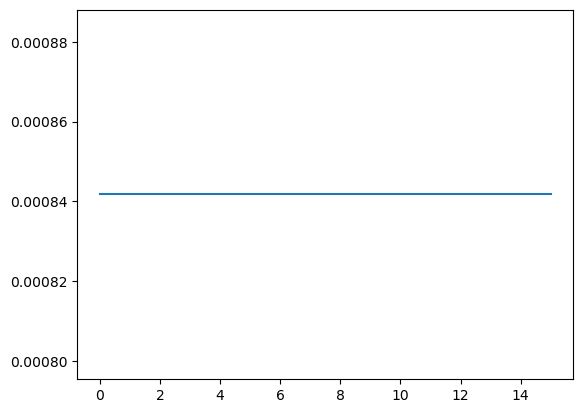

In [24]:
plot_width(grip_replay)

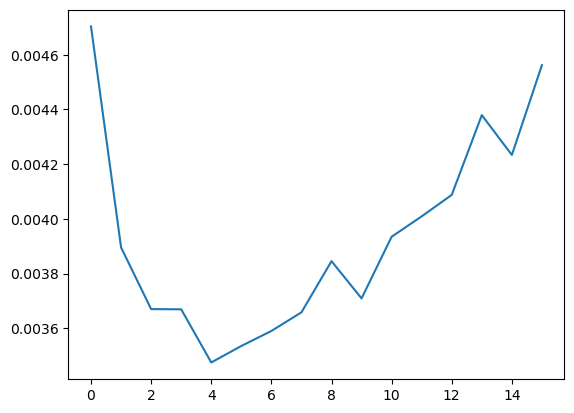

In [25]:
plot_width(real_umi_action)
# -0.45 ~ -0.51 (before)
# 0.024 ~ 0.010 (after i fixed my mistake)

In [26]:
tx_base_tag = np.array([
        [
      -0.9992668101498986,
      0.03786236221936187,
      0.005681871172127269,
      -0.018283582081895254
    ],
    [
      -0.03760656116820821,
      -0.998497334760624,
      0.03985999288801041,
      -0.49712673959771314
    ],
    [
      0.007182526710609295,
      0.03961709231001545,
      0.9991891198901993,
      -0.042018964151028
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
  
  ])

tx_tag_base = np.linalg.inv(tx_base_tag)

plot_transformation(tx_base_tag, scale=0.1, frame_name="TX Base Tag")

In [27]:
tx_base_tag2 = np.array([
      [
      -0.008599961538357362,
      -0.9996651451709792,
      0.024405699986351576,
      -0.027373312962385425
    ],
    [
      0.7222428696783785,
      0.010670250020573736,
      0.6915572159722135,
      -0.47149854126204277
    ],
    [
      -0.6915860596196822,
      0.02357420825358666,
      0.7219092594259595,
      0.057772199877069316
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]]
)

tx_base_tag3 = np.array([
        [
      -0.9987326664486069,
      -0.05030916415478115,
      0.001431422545086991,
      -0.027316612639236567
    ],
    [
      0.050262709660816085,
      -0.9984683399599527,
      -0.023122156369348515,
      -0.5784779977762492
    ],
    [
      0.0025924864527723246,
      -0.023020905709015438,
      0.999731622443908,
      0.04033151752109664
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
]
)

In [28]:
tx_slam_tag = np.array([
    
    [
      0.999010800224083,
      0.04419283883966596,
      -0.00493732584247188,
      -0.038451282666388954
    ],
    [
      0.019925677699674696,
      -0.5441419461595277,
      -0.8387565327949628,
      0.10049407623530243
    ],
    [
      -0.039753639276792485,
      0.8378284779205093,
      -0.5444842672810158,
      0.5594021977928332
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
])

In [29]:
plot_transformation(tx_base_tag2, scale=0.1, frame_name="TX Base Tag 2")

In [30]:
plot_transformation(tx_base_tag3, scale=0.1, frame_name="TX Base Tag 3")

In [31]:
tcp_offset = 0.205
cam_to_center_height = 0.086
cam_to_mount_offset = 0.01465
cam_to_tip_offset = cam_to_mount_offset + tcp_offset
pose_cam_tcp = np.array([0, cam_to_center_height, cam_to_tip_offset, 0,0,0])
tx_cam_tcp = pose_to_mat(pose_cam_tcp)

In [32]:
plot_transformation(T=tx_cam_tcp, scale=0.1, frame_name="TX Cam TCP")

In [33]:
fig = go.Figure()
for i, tx in enumerate([tx_base_tag, tx_tag_base, tx_cam_tcp], start=1):
    traces = get_frame_traces(tx, scale=0.1, frame_name=f"Frame {i}")
    for trace in traces:
        fig.add_trace(trace)

fig.update_layout(scene=dict(aspectmode='data'),
                  title="Multiple Transformation Matrices")
fig.show()

In [34]:
fig = go.Figure()
for i, tx in enumerate([tx_tag_base, tx_slam_tag, tx_cam_tcp], start=1):
    traces = get_frame_traces(tx, scale=0.1, frame_name=f"Frame {i}")
    for trace in traces:
        fig.add_trace(trace)

fig.update_layout(scene=dict(aspectmode='data'),
                  title="Multiple Transformation Matrices")
fig.show()

In [35]:
fig = go.Figure()
for i, tx in enumerate([tx_base_tag, tx_base_tag2, tx_base_tag3], start=1):
    traces = get_frame_traces(tx, scale=0.1, frame_name=f"Frame {i}")
    for trace in traces:
        fig.add_trace(trace)

fig.update_layout(scene=dict(aspectmode='data'),
                  title="Multiple Transformation Matrices")
fig.show()

In [36]:
def plot_pos_multi(ax, pose_comms, title=""):
    # Extract x, y, z coordinates
    x = pose_comms[:, 0]
    y = pose_comms[:, 1]
    z = pose_comms[:, 2]

    # Generate colors based on order (index)
    colors = np.linspace(0, 1, len(x))  # Normalize order for color mapping

    # Scatter plot with gradient colors
    sc = ax.scatter(x, y, z, c=colors, cmap='cool', s=50)

    # Add labels
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)

[181 183 157 204  95  13  89 118 109 121 110  23 131  29  47  56]


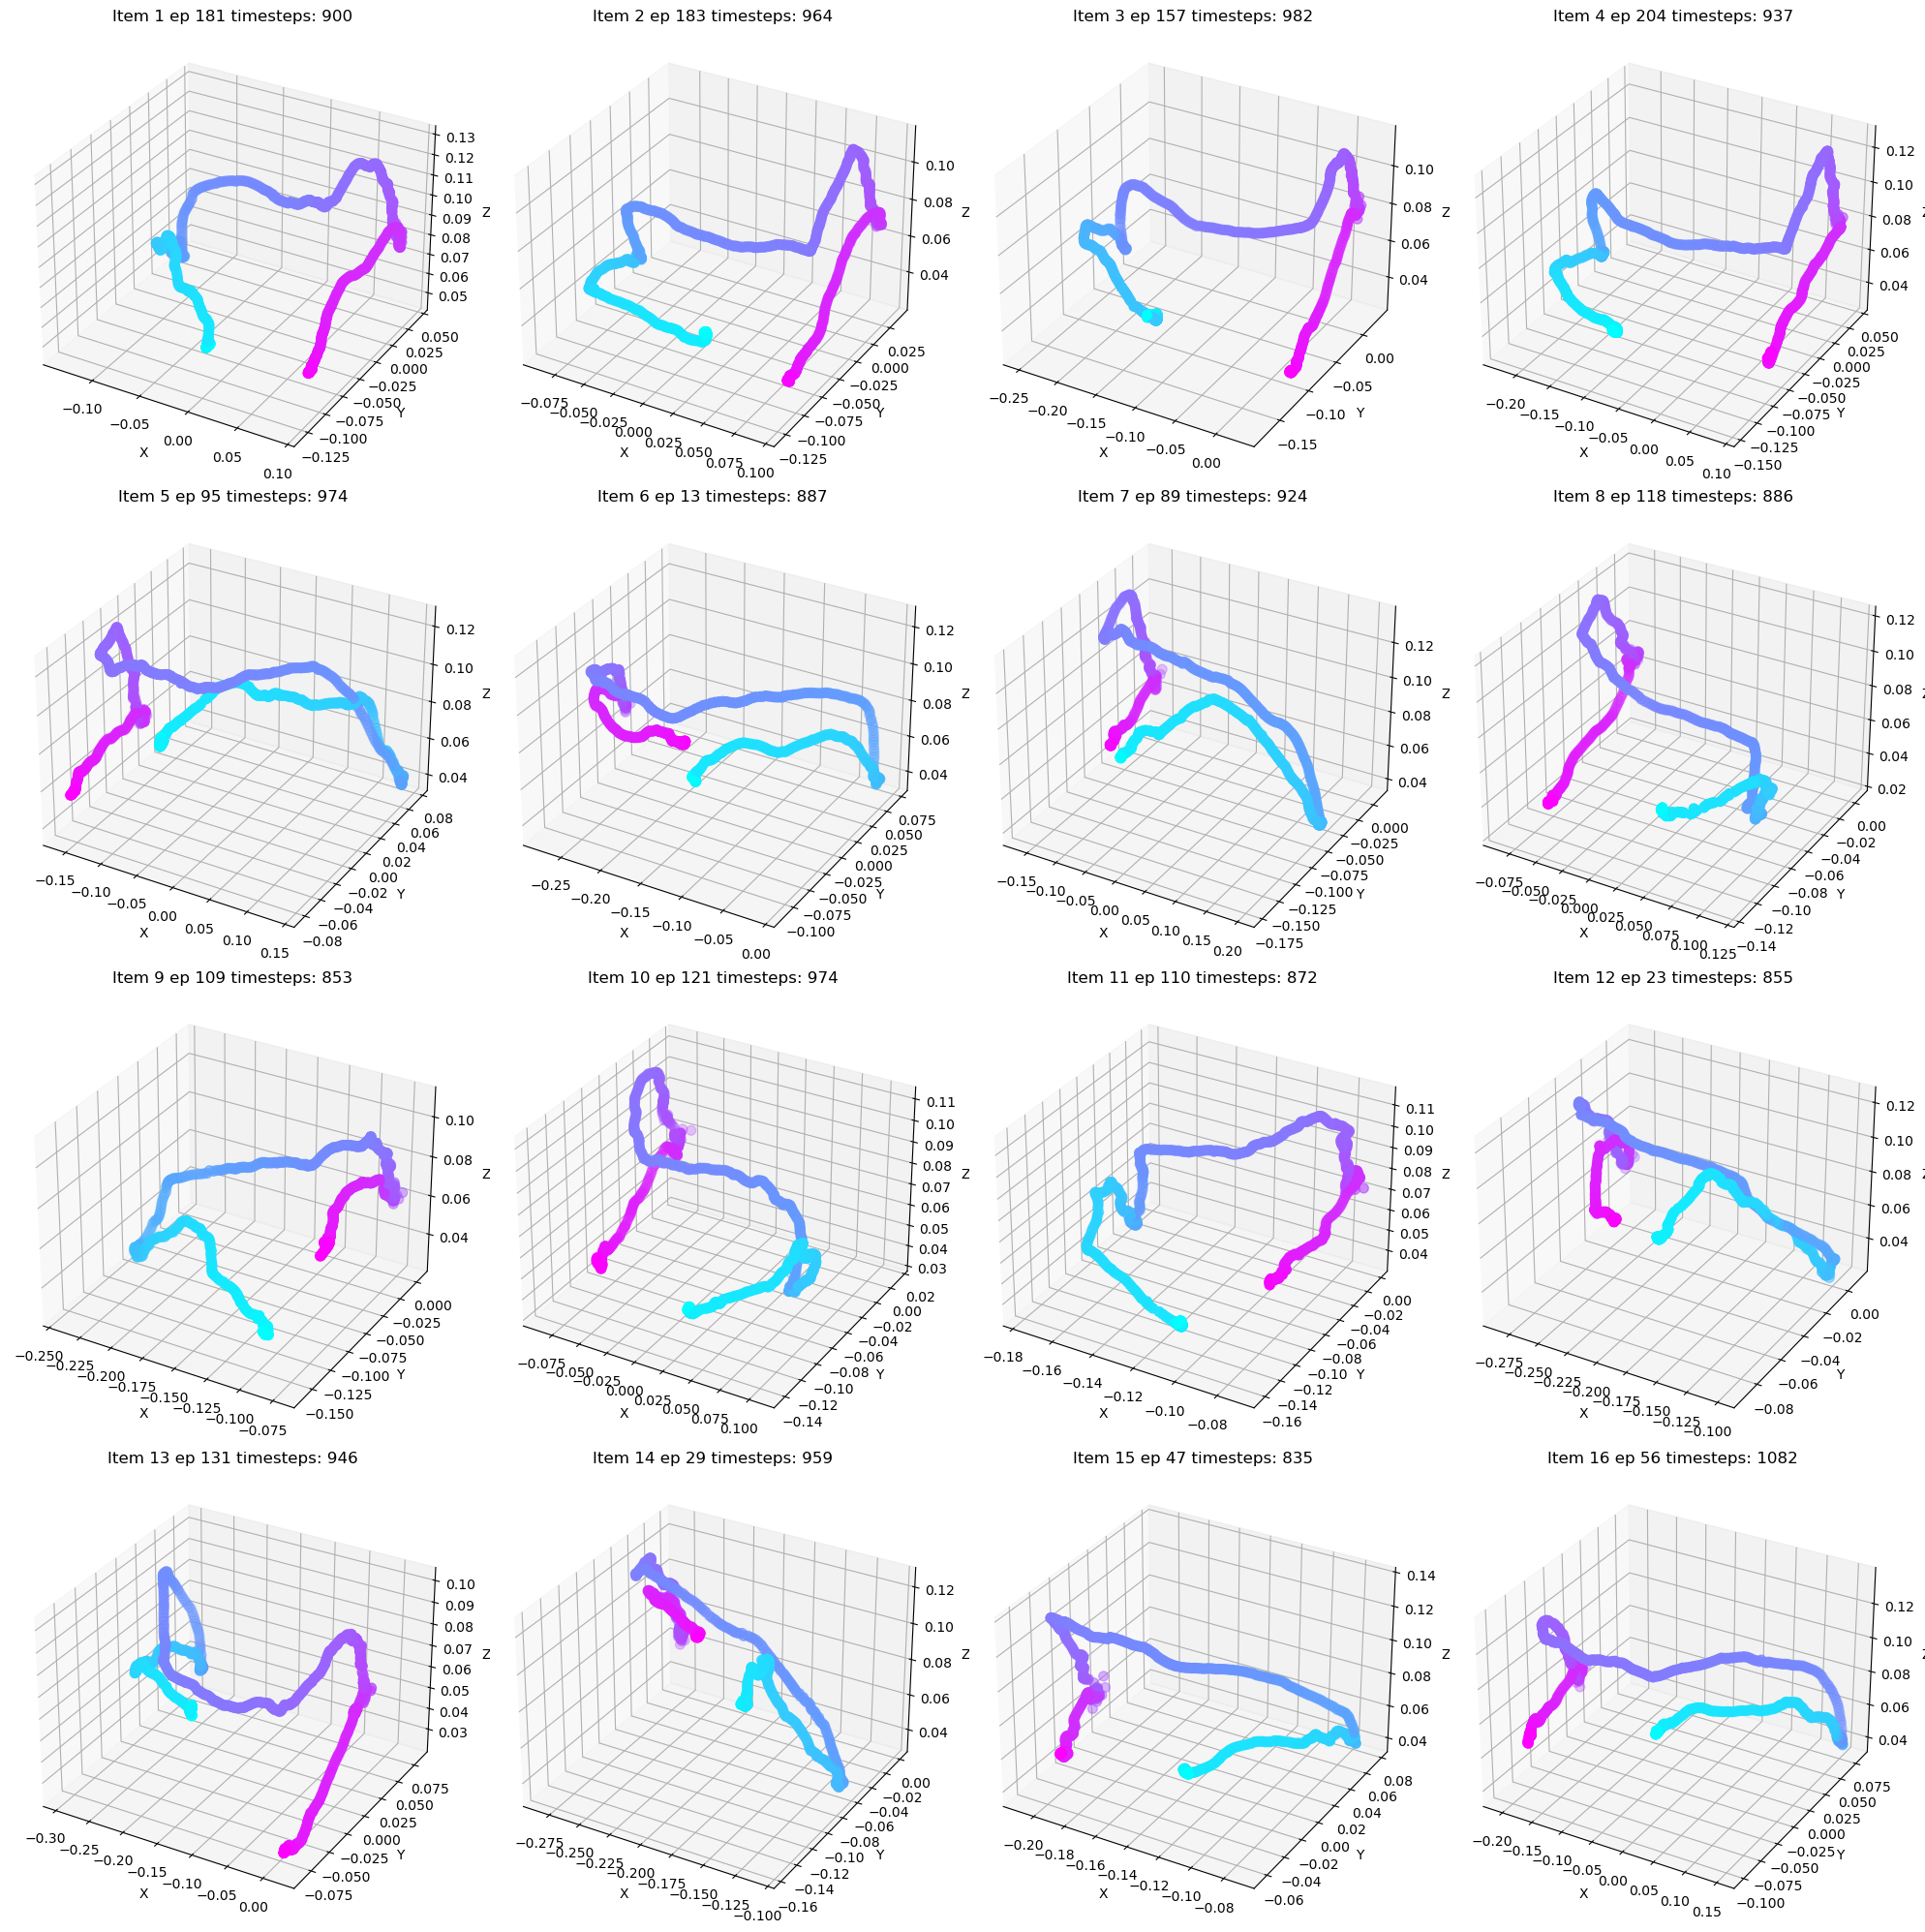

In [37]:
num_episodes = len(replay_buffer.episode_ends)
num_episodes_random = 16
random_episodes = np.random.choice(num_episodes, num_episodes_random, replace=False)
print(random_episodes)
fig = plt.figure(figsize=(20, 20))
rows = int(np.ceil(np.sqrt(num_episodes_random)))
cols = int(np.ceil(num_episodes_random / rows))
for idx, ep_idx in enumerate(random_episodes):
    episode = replay_buffer.get_episode(ep_idx)
    each_pos_replay = episode['robot0_eef_pos'][:]

    ax = fig.add_subplot(rows, cols, idx + 1, projection='3d')
    plot_pos_multi(ax, each_pos_replay, title=f"Item {idx+1} ep {ep_idx} timesteps: {len(episode['robot0_eef_pos'])}")

plt.tight_layout()
plt.show()

In [38]:
mean_start_pos_list = list()
mean_start_rot_list = list()
num_episodes = len(replay_buffer.episode_ends)

for ep_idx in range(num_episodes):
    episode = replay_buffer.get_episode(ep_idx)
    each_pos_replay = episode['robot0_eef_pos'][:]
    each_rot_replay = episode['robot0_eef_rot_axis_angle'][:]

    each_ep_length = len(each_pos_replay)
    start_duration = int(each_ep_length * 0.005)
    print(f"ep {ep_idx} with duration {start_duration}")

    each_start_pos = episode['robot0_eef_pos'][:start_duration]
    mean_start_pos_list.append(each_start_pos)

    each_start_rot = episode['robot0_eef_rot_axis_angle'][:start_duration]
    mean_start_rot_list.append(each_start_rot)


ep 0 with duration 6
ep 1 with duration 8
ep 2 with duration 9
ep 3 with duration 8
ep 4 with duration 8
ep 5 with duration 9
ep 6 with duration 3
ep 7 with duration 4
ep 8 with duration 3
ep 9 with duration 3
ep 10 with duration 4
ep 11 with duration 4
ep 12 with duration 4
ep 13 with duration 4
ep 14 with duration 5
ep 15 with duration 4
ep 16 with duration 5
ep 17 with duration 5
ep 18 with duration 5
ep 19 with duration 4
ep 20 with duration 5
ep 21 with duration 4
ep 22 with duration 4
ep 23 with duration 4
ep 24 with duration 4
ep 25 with duration 4
ep 26 with duration 4
ep 27 with duration 4
ep 28 with duration 4
ep 29 with duration 4
ep 30 with duration 4
ep 31 with duration 5
ep 32 with duration 4
ep 33 with duration 5
ep 34 with duration 5
ep 35 with duration 4
ep 36 with duration 5
ep 37 with duration 4
ep 38 with duration 4
ep 39 with duration 5
ep 40 with duration 5
ep 41 with duration 5
ep 42 with duration 4
ep 43 with duration 4
ep 44 with duration 5
ep 45 with duration 

In [39]:
mean_start_pos_array = np.concatenate(mean_start_pos_list, axis=0)
mean_start_rot_array = np.concatenate(mean_start_rot_list, axis=0)

In [40]:
mean_x = np.mean(mean_start_pos_array[:, 0])
mean_y = np.mean(mean_start_pos_array[:, 1])
mean_z = np.mean(mean_start_pos_array[:, 2])

mean_rx = np.mean(mean_start_rot_array[:, 0])
mean_ry = np.mean(mean_start_rot_array[:, 1])
mean_rz = np.mean(mean_start_rot_array[:, 2])


In [41]:
some_x = np.mean(mean_start_pos_array[:5, 0])
some_y = np.mean(mean_start_pos_array[:5, 1])
some_z = np.mean(mean_start_pos_array[:5, 2])

some_rx = np.mean(mean_start_rot_array[:5, 0])
some_ry = np.mean(mean_start_rot_array[:5, 1])
some_rz = np.mean(mean_start_rot_array[:5, 2])

In [42]:
mean_x # -0.08782661


-0.057284143

In [43]:
mean_y # -0.13807559
# -0.13376735


-0.13529727

In [44]:
mean_z # 0.093378246
# 0.09266995


0.09367344

In [45]:
mean_rx
# -2.1256728

-2.124752

In [46]:
mean_ry
# 0.0827507


0.082834415

In [47]:
mean_rz
# 0.052626412

0.052807067

In [48]:
import time
import rtde_control
from rtde_control import RTDEControlInterface
from rtde_io import  RTDEIOInterface
from rtde_receive import RTDEReceiveInterface

In [ ]:
# mean_x = 0.058042273
# mean_y = -0.13376735
# mean_z = 0.09266995
# mean_rx = -2.1256728
# mean_ry = 0.0827507
# mean_rz = 0.052626412

In [ ]:
ur_ip = "192.168.3.168" 

In [ ]:
rtde_c = RTDEControlInterface(ur_ip)

In [ ]:
rtde_r = RTDEReceiveInterface(ur_ip)

In [ ]:
target_pose = np.array([mean_x, mean_y, mean_z, mean_rx, mean_ry, mean_rz])
some_target_pose = np.array([some_x, some_y, some_z, some_rx, some_ry, some_rz])

In [ ]:
calib = {
  "tx_base2world": [
    [
      -0.9992668101498986,
      0.03786236221936187,
      0.005681871172127269,
      -0.018283582081895254
    ],
    [
      -0.03760656116820821,
      -0.998497334760624,
      0.03985999288801041,
      -0.49712673959771314
    ],
    [
      0.007182526710609295,
      0.03961709231001545,
      0.9991891198901993,
      -0.042018964151028
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
  ],
}

calib

In [ ]:
from umi.common.pose_util import pose_to_mat, mat_to_pose

In [ ]:
def from_base_to_tcp(pose_tag_tcp, tx_base_tag):
    tx_tag_base = np.linalg.inv(tx_base_tag)
    
    tx_tag_tcp = pose_to_mat(pose_tag_tcp)
    tx_base_tcp = tx_tag_base @ tx_tag_tcp
    # tx_base_tcp = tx_base_tag @ tx_tag_tcp
    pose_base_tcp = mat_to_pose(tx_base_tcp)
    return pose_base_tcp

In [ ]:
target_pose_base_tcp = from_base_to_tcp(target_pose, calib['tx_base2world'])
target_pose_base_tcp

In [ ]:
some_target_pose_base_tcp = from_base_to_tcp(some_target_pose, calib['tx_base2world'])
some_target_pose_base_tcp

In [ ]:
rtde_r.getActualTCPPose()
    # x axis (right - /left +)
    # y axis (front - / back +)
    # z axis (up + /down - )

In [ ]:
# pose_base_tcp = some_pose_base_tcp
pose_base_tcp = some_target_pose

# initial_pose = np.array([-0.08909736, -0.20554989,  0.30928412,  1.86559811,  1.5479944,  -0.57837145])

In [ ]:
duration = 20.0  
lookahead_time = 0.1  
gain = 300.0
velocity = 0.5  
acceleration = 0.5

# Move using servoL
rtde_c.servoL(pose_base_tcp, velocity, acceleration, duration, lookahead_time, gain)

# Keep sending commands to maintain servoL (It requires continuous updates)
start_time = time.time()
while time.time() - start_time < duration:
    rtde_c.servoL(pose_base_tcp, velocity, acceleration, duration, lookahead_time, gain)
    time.sleep(0.008)  # Update every 8ms (recommended)


In [ ]:
rtde_c.disconnect()